Dataset:
   Rainfall  WaterLevel  Humidity  Temperature  Flood
0       120         6.5        80           30      1
1        60         3.2        60           35      0
2       150         8.1        90           28      1
3        80         4.5        70           32      0
4       180         9.0        95           27      1
5        50         3.8        65           34      0
6       140         7.5        88           29      1
7        70         3.5        62           33      0
8       160         7.0        85           30      1
9        90         4.0        68           31      0

KNN Model trained successfully!


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


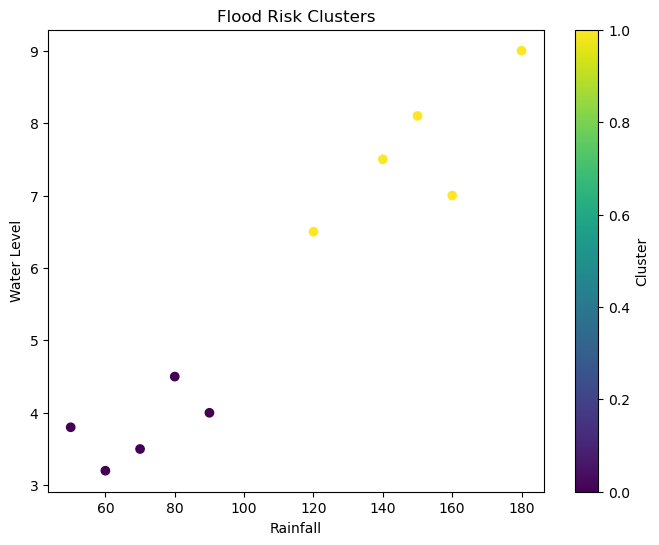


Sample Predictions:
Sample 1: Rainfall=150, WaterLevel=8.0, Humidity=85, Temp=28 -> Flood Likely
Sample 2: Rainfall=60, WaterLevel=3.0, Humidity=65, Temp=35 -> No Flood


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


'\n# Flask Web App (Save this in a separate .py file to run)\napp = Flask(__name__)\n\n@app.route("/")\ndef home():\n    return \'\'\'\n    <h2>Rising Waters: Flood Prediction</h2>\n    <form action="/predict" method="post">\n    Rainfall:<br>\n    <input name="rainfall"><br><br>\n    Water Level:<br>\n    <input name="water"><br><br>\n    Humidity:<br>\n    <input name="humidity"><br><br>\n    Temperature:<br>\n    <input name="temp"><br><br>\n    <input type="submit" value="Predict">\n    </form>\n    \'\'\'\n\n@app.route("/predict", methods=["POST"])\ndef predict():\n    rainfall = float(request.form["rainfall"])\n    water = float(request.form["water"])\n    humidity = float(request.form["humidity"])\n    temp = float(request.form["temp"])\n\n    sample = np.array([[rainfall, water, humidity, temp]])\n    prediction = model.predict(sample)\n\n    result = "Flood Likely" if prediction[0] == 1 else "No Flood"\n\n    return f\'\'\'\n    <h2>Prediction Result</h2>\n    <h3>{result}</h3

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from flask import Flask, request

# Fix the data dictionary - add the missing "Rainfall" key
data = {
    "Rainfall": [120, 60, 150, 80, 180, 50, 140, 70, 160, 90],  # Added missing Rainfall data
    "WaterLevel": [6.5, 3.2, 8.1, 4.5, 9.0, 3.8, 7.5, 3.5, 7.0, 4.0],
    "Humidity": [80, 60, 90, 70, 95, 65, 88, 62, 85, 68],
    "Temperature": [30, 35, 28, 32, 27, 34, 29, 33, 30, 31],
    "Flood": [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]
}

df = pd.DataFrame(data)
print("Dataset:")
print(df)

# -----------------------------
# Machine Learning Model (KNN)
# -----------------------------
X = df[["Rainfall", "WaterLevel", "Humidity", "Temperature"]]
y = df["Flood"]

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X, y)
print("\nKNN Model trained successfully!")

# -----------------------------
# K-Means Clustering
# -----------------------------
kmeans = KMeans(n_clusters=2, random_state=0)
clusters = kmeans.fit_predict(df[["Rainfall", "WaterLevel"]])

# -----------------------------
# Graph
# -----------------------------
plt.figure(figsize=(8, 6))
plt.scatter(df["Rainfall"], df["WaterLevel"], c=clusters, cmap='viridis')
plt.xlabel("Rainfall")
plt.ylabel("Water Level")
plt.title("Flood Risk Clusters")
plt.colorbar(label='Cluster')
plt.show()

# -----------------------------
# Test the model with sample predictions
# -----------------------------
print("\nSample Predictions:")
test_samples = [
    [150, 8.0, 85, 28],  # High rainfall, high water level
    [60, 3.0, 65, 35]    # Low rainfall, low water level
]

for i, sample in enumerate(test_samples):
    prediction = model.predict([sample])
    result = "Flood Likely" if prediction[0] == 1 else "No Flood"
    print(f"Sample {i+1}: Rainfall={sample[0]}, WaterLevel={sample[1]}, Humidity={sample[2]}, Temp={sample[3]} -> {result}")

# Note: Flask web app code is commented out as it's not suitable for Jupyter notebooks
# To run the Flask app, save it in a separate .py file and run it from terminal

"""
# Flask Web App (Save this in a separate .py file to run)
app = Flask(__name__)

@app.route("/")
def home():
    return '''
    <h2>Rising Waters: Flood Prediction</h2>
    <form action="/predict" method="post">
    Rainfall:<br>
    <input name="rainfall"><br><br>
    Water Level:<br>
    <input name="water"><br><br>
    Humidity:<br>
    <input name="humidity"><br><br>
    Temperature:<br>
    <input name="temp"><br><br>
    <input type="submit" value="Predict">
    </form>
    '''

@app.route("/predict", methods=["POST"])
def predict():
    rainfall = float(request.form["rainfall"])
    water = float(request.form["water"])
    humidity = float(request.form["humidity"])
    temp = float(request.form["temp"])
    
    sample = np.array([[rainfall, water, humidity, temp]])
    prediction = model.predict(sample)
    
    result = "Flood Likely" if prediction[0] == 1 else "No Flood"
    
    return f'''
    <h2>Prediction Result</h2>
    <h3>{result}</h3>
    <a href="/">Predict Again</a>
    '''

if __name__ == "__main__":
    app.run(debug=True)
"""